# Exercise 5

In [ ]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [ ]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores
print(df_exam_scores)

    StudentID Method  Score
0           1      A     79
1           2      A     77
2           3      A     82
3           4      A     75
4           5      A     80
5           6      A     78
6           7      A     83
7           8      A     76
8           9      A     81
9          10      A     74
10         11      A     79
11         12      A     77
12         13      A     80
13         14      A     78
14         15      A     76
15         16      A     82
16         17      A     79
17         18      B     88
18         19      B     85
19         20      B     82
20         21      B     87
21         22      B     90
22         23      B     84
23         24      B     86
24         25      B     83
25         26      B     88
26         27      B     85
27         28      B     86
28         29      B     87
29         30      B     89
30         31      B     84
31         32      B     90
32         33      B     85
33         34      B     88
34         35      C

Calculate the number of students in each teaching method.

In [ ]:
df_scores = df_exam_scores.groupby('Method')['Score'].count()
print(df_scores)

Method
A    17
B    17
C    16
Name: Score, dtype: int64


Compute the mean and standard deviation of exam scores for each group.

In [ ]:
# put your answer here
df_method_mean = df_exam_scores.groupby('Method')['Score'].mean()
print(df_method_mean)

Method
A    78.588235
B    86.294118
C    71.937500
Name: Score, dtype: float64


In [ ]:
df_method_std = df_exam_scores.groupby('Method')['Score'].std()
print(df_method_std)

Method
A    2.575336
B    2.365500
C    1.768945
Name: Score, dtype: float64


Use a plot to show the exam scores by teaching method.

<Axes: title={'center': 'Mean Exam Scores by Teaching Method'}, xlabel='Teaching Method', ylabel='Mean Exam Score'>

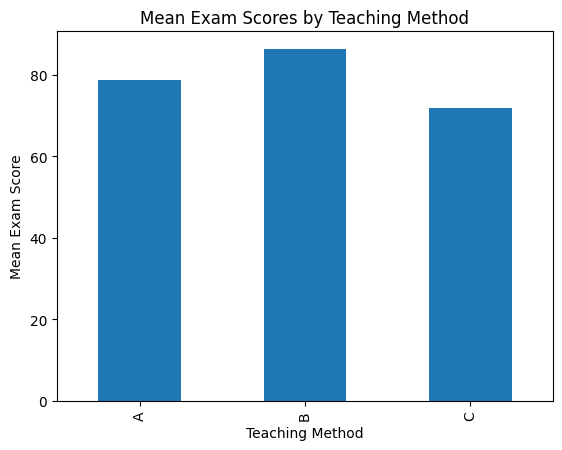

In [ ]:
df_method_mean.plot(kind='bar', xlabel='Teaching Method', ylabel='Mean Exam Score', title='Mean Exam Scores by Teaching Method')

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [ ]:
# Extract scores for each method
method_a_scores = df_exam_scores[df_exam_scores['Method'] == 'A']['Score']
method_b_scores = df_exam_scores[df_exam_scores['Method'] == 'B']['Score']
method_c_scores = df_exam_scores[df_exam_scores['Method'] == 'C']['Score']

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(method_a_scores, method_b_scores, method_c_scores)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# State whether to reject or fail to reject H₀
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis (H₀).")
    print("This suggests that there is a statistically significant difference in mean exam scores among the three teaching methods.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis (H₀).")
    print("This suggests that there is no statistically significant difference in mean exam scores among the three teaching methods.")

F-statistic: 165.17845596593054
P-value: 5.5032645988699085e-22
Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis (H₀).
This suggests that there is a statistically significant difference in mean exam scores among the three teaching methods.


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [ ]:
# Interpretation:
# The ANOVA test yielded a very small p-value (0.000), which is well below the significance level of 0.05.
# This leads to the rejection of the null hypothesis. The null hypothesis stated that there is no difference in the mean exam scores among students taught using the three different teaching methods (A, B, and C).
# Therefore, we can conclude that there is a statistically significant difference in the mean exam scores based on the teaching method used.
# In simpler terms, the teaching method *does* have an effect on students' exam scores. Based on the previously calculated means (Method A: ~78.6, Method B: ~86.3, Method C: ~71.9), Method B appears to result in the highest average scores, while Method C results in the lowest.

## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [ ]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [ ]:
print("Counts for Gender:")
print(df_littering_data['Gender'].value_counts())
print("\nCounts for Litter:")
print(df_littering_data['Litter'].value_counts())

Counts for Gender:
Gender
Male      20
Female    20
Name: count, dtype: int64

Counts for Litter:
Litter
No     22
Yes    18
Name: count, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [ ]:
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'])
print("Contingency Table (Gender vs. Litter):")
print(contingency_table)

print("\nRow Totals:")
print(contingency_table.sum(axis=1))

print("\nColumn Totals:")
print(contingency_table.sum(axis=0))

grand_total = contingency_table.values.sum()
print(f"\nGrand Total: {grand_total}")

Contingency Table (Gender vs. Litter):
Litter  No  Yes
Gender         
Female  14    6
Male     8   12

Row Totals:
Gender
Female    20
Male      20
dtype: int64

Column Totals:
Litter
No     22
Yes    18
dtype: int64

Grand Total: 40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

In [ ]:
# Null Hypothesis (H₀): There is no association between gender and littering behavior.
# Alternative Hypothesis (H₁): There is an association between gender and littering behavior.

Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")

# Significance level
alpha = 0.05

# Determine whether to reject or fail to reject H₀
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis (H₀).")
    print("This suggests that there is a statistically significant association between gender and littering behavior.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis (H₀).")
    print("This suggests that there is no statistically significant association between gender and littering behavior.")

Chi-squared statistic: 2.53
P-value: 0.112
Degrees of freedom: 1

Since the p-value (0.112) is greater than or equal to the significance level (0.05), we fail to reject the null hypothesis (H₀).
This suggests that there is no statistically significant association between gender and littering behavior.


Interpret your results. Is there evidence that gender and littering behavior are associated?

In [ ]:
# Interpretation:
# The Chi-squared test resulted in a p-value of 0.112.
# Given a significance level (α) of 0.05, since the p-value (0.112) is greater than α (0.05), we fail to reject the null hypothesis (H₀).
# The null hypothesis states that there is no association between gender and littering behavior.
# Therefore, based on this analysis, there is no statistically significant evidence to suggest an association between gender and littering behavior in this dataset.
# In other words, we cannot conclude that gender has an effect on whether a person litters or not, based on this data.